In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')
SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit)

In [3]:
sfg_crit = SPECTRA.SFG_criteria(exclude=False)
qso_crit = SPECTRA.subtype_criteria(subtype='QSO', exclude=True)
SPECTRA.subset(criteria=sfg_crit & qso_crit)
SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)

In [366]:
# test_id = 39627770237553909
# test_idx = SPECTRA.id2index(test_id)


test_idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
test_id = SPECTRA.targetID[test_idx]


Number of emission lines > 8 S/N: 6


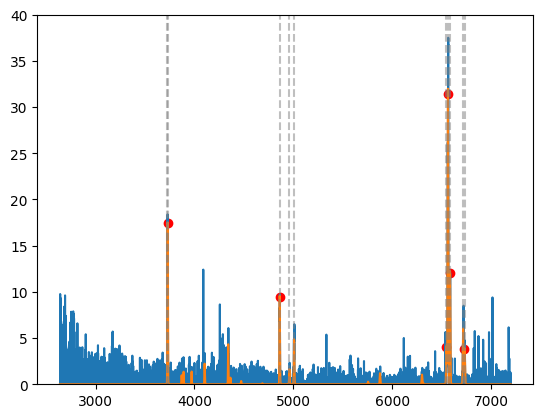

In [367]:

plt.plot(SPECTRA.data_stack[test_idx,0,:], SPECTRA.data_stack[test_idx,1,:])
plt.plot(SPECTRA.data_stack[test_idx,0,:], SPECTRA.data_stack[test_idx,5,:])
# plt.plot(SPECTRA.data_stack[test_idx,0,:], 8/SPECTRA.data_stack[test_idx,2,:])
# plt.xlim([OII_rest[0]-30, OII_rest[0]+30])
# plt.xlim([Halpha_rest[0]-30, Halpha_rest[0]+30])
# plt.xlim([SII_rest[0]-30, SII_rest[0]+30])
plt.ylim([0, 40])
count = 0
for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]: # total 10 lines
    plt.axvline(l0, color='gray', linestyle='--', alpha=0.5)
    l0_idx = np.searchsorted(SPECTRA.data_stack[test_idx,0,:], l0)  - 1 # -1 is because searchsorted gives the index where it would be inserted to keep order
    if SPECTRA.data_stack[test_idx,5,l0_idx] > 8/SPECTRA.data_stack[test_idx,2,l0_idx]:
        count += 1
        plt.scatter(SPECTRA.data_stack[test_idx,0,l0_idx], SPECTRA.data_stack[test_idx,5,l0_idx], color='red')

print(f"Number of emission lines > 8 S/N: {count}")
plt.show()